In [ ]:
# # India School Education Analysis (UDISE Data)

#**A portfolio data analysis project** exploring India's state/UT-level school
# infrastructure and social-category enrollment patterns.

 #**Datasets used:**
#- `school_infrastructure.csv` — schools, enrolments, teachers, pupil-teacher ratio (PTR), and single-teacher / zero-enrolment school counts per State/UT
#- `social_category_enrollment.csv` — % share of enrollment by social category (General, SC, ST, OBC, Muslim) per State/UT

# **Goal:** identify infrastructure gaps (overcrowding, single-teacher schools) and see how enrollment composition varies across states.

In [1]:
import pandas as pd #Imports Pandas to work with tables and datasets.
import matplotlib.pyplot as plt  #Imports Matplotlib to create graphs and charts
import seaborn as sns #Imports Seaborn to make attractive statistical visualizations.

In [3]:
sns.set_theme(style="whitegrid")  #Sets the graph background to a white grid style
plt.rcParams["figure.dpi"] = 110  #Sets the graph resolution to 110 DPI for better clarity.

In [4]:
# loaded files
infra = pd.read_csv(r"C:\Users\B Puri Keshava\Desktop\school_infrastructure.csv")
social = pd.read_csv(r"C:\Users\B Puri Keshava\Desktop\social_category_enrollment.csv")

In [5]:
infra.head() # verify infra dataset

,India/State/UT,Total number of Schools,Enrolments,Teachers,Pupil Teacher Ratio,Average Teachers Per School,Average Enrolments Per School,Schools with Zero Enrolments,Teachers in schools having zero Enrolments,Schools with Single Teachers,Enrolments in Single Teacher Schools
0,Andaman & Nicobar Islands,411,71297,6137,12,15,173,0,0,1,4
1,Andhra Pradesh,60843,8437049,353745,24,6,139,10,13,16357,231631
2,Arunachal Pradesh,3159,320836,25277,13,8,102,134,70,473,5556
3,Assam,55333,7045062,345219,20,6,127,0,0,3159,101848
4,Bihar,95285,20696191,728945,28,8,217,0,0,2006,162393


In [6]:
social.head() #verify social dataset

,State/UT,General,SC,ST,OBC,Muslim
0,Andaman & Nicobar Islands,62.7,0.7,9.6,27.0,10.4
1,Andhra Pradesh,21.6,19.6,7.2,51.6,9.0
2,Arunachal Pradesh,21.1,1.8,72.8,4.3,2.1
3,Assam,51.3,7.4,14.9,26.4,41.7
4,Bihar,14.9,18.1,1.9,65.0,17.4


In [8]:
infra.columns = [c.strip() for c in infra.columns]  #Removes extra spaces from all column names in
social.columns = [c.strip() for c in social.columns] #Removes extra spaces from all column names in
infra = infra.rename(columns={"India/State/UT": "State/UT"}) #Renames the column to State/UT so both datasets have the same column name.
infra["State/UT"] = infra["State/UT"].str.strip() #Removes extra spaces from the values in the State/UT column.
social["State/UT"] = social["State/UT"].str.strip() #emoves extra spaces from the values in the State/UT column of the second dataset.

In [9]:
# Separate the all-India total row from individual states/UTs
infra_states = infra[~infra["State/UT"].str.contains("India", case=False, na=False)].copy()
social_states = social[~social["State/UT"].str.contains("India", case=False, na=False)].copy()

df = pd.merge(infra_states, social_states, on="State/UT", how="inner")
print(f"States/UTs after merge: {df.shape[0]}")
df.head()

States/UTs after merge: 36


,State/UT,Total number of Schools,Enrolments,Teachers,Pupil Teacher Ratio,Average Teachers Per School,Average Enrolments Per School,Schools with Zero Enrolments,Teachers in schools having zero Enrolments,Schools with Single Teachers,Enrolments in Single Teacher Schools,General,SC,ST,OBC,Muslim
0,Andaman & Nicobar Islands,411,71297,6137,12,15,173,0,0,1,4,62.7,0.7,9.6,27.0,10.4
1,Andhra Pradesh,60843,8437049,353745,24,6,139,10,13,16357,231631,21.6,19.6,7.2,51.6,9.0
2,Arunachal Pradesh,3159,320836,25277,13,8,102,134,70,473,5556,21.1,1.8,72.8,4.3,2.1
3,Assam,55333,7045062,345219,20,6,127,0,0,3159,101848,51.3,7.4,14.9,26.4,41.7
4,Bihar,95285,20696191,728945,28,8,217,0,0,2006,162393,14.9,18.1,1.9,65.0,17.4


In [13]:
################################################ NATIONAL OVERVIEW #####################################################
national = {
    "Total Schools": 1466682,
    "Total Enrolments": 247219766,
    "Total Teachers": 10273020,
    "Average Pupil-Teacher Ratio": 20.4,
    "Single-Teacher Schools": 100843,
    "Zero-Enrolment Schools": 5663
}

for k, v in national.items():
    print(f"{k}: {v:,}")

Total Schools: 1,466,682
Total Enrolments: 247,219,766
Total Teachers: 10,273,020
Average Pupil-Teacher Ratio: 20.4
Single-Teacher Schools: 100,843
Zero-Enrolment Schools: 5,663


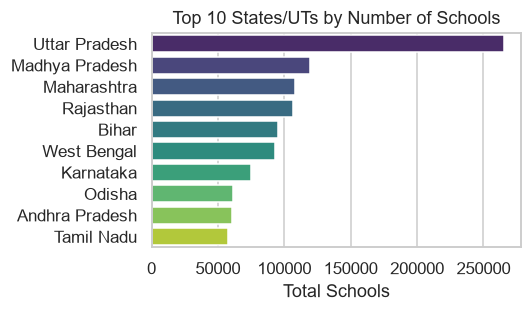

In [15]:
############################################# STATES VS SCHOOLS ###############################################################
top10_schools = infra_states.sort_values("Total number of Schools", ascending=False).head(10)
plt.figure(figsize=(5, 3))
sns.barplot(data=top10_schools, y="State/UT", x="Total number of Schools", hue="State/UT", palette="viridis", legend=False)
plt.title("Top 10 States/UTs by Number of Schools")
plt.xlabel("Total Schools"); plt.ylabel("")
plt.tight_layout()
plt.show()

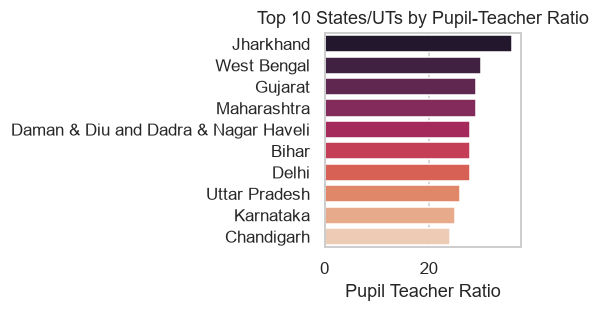

In [19]:
################################HIGHEST PUPIL RATIO OF TEACHERS #####################################################
top10_ptr = infra_states.sort_values("Pupil Teacher Ratio", ascending=False).head(10)
plt.figure(figsize=(5, 3))
sns.barplot(data=top10_ptr, y="State/UT", x="Pupil Teacher Ratio", hue="State/UT", palette="rocket", legend=False)
plt.title("Top 10 States/UTs by Pupil-Teacher Ratio")
plt.xlabel("Pupil Teacher Ratio"); plt.ylabel("")
plt.tight_layout()
plt.show()

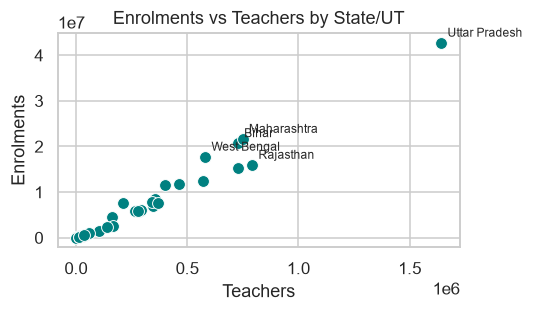

In [18]:
########################## ENROLLMENTS VS STUDENTS ###########################################################
plt.figure(figsize=(5, 3))
sns.scatterplot(data=infra_states, x="Teachers", y="Enrolments", s=60, color="teal")
for _, row in infra_states.nlargest(5, "Enrolments").iterrows():
    plt.annotate(row["State/UT"], (row["Teachers"], row["Enrolments"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
plt.title("Enrolments vs Teachers by State/UT")
plt.tight_layout()
plt.show()

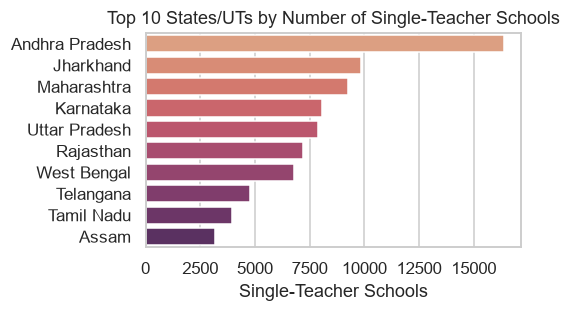

In [21]:
############################## Single-Teacher Schools — Where Are They Concentrated?########################################
Single-teacher schools are a common proxy for under-resourced, often remote, rural schooling.
top10_single = infra_states.sort_values("Schools with Single Teachers", ascending=False).head(10)
plt.figure(figsize=(5, 3))
sns.barplot(data=top10_single, y="State/UT", x="Schools with Single Teachers", hue="State/UT", palette="flare", legend=False)
plt.title("Top 10 States/UTs by Number of Single-Teacher Schools")
plt.xlabel("Single-Teacher Schools"); plt.ylabel("")
plt.tight_layout()
plt.show()

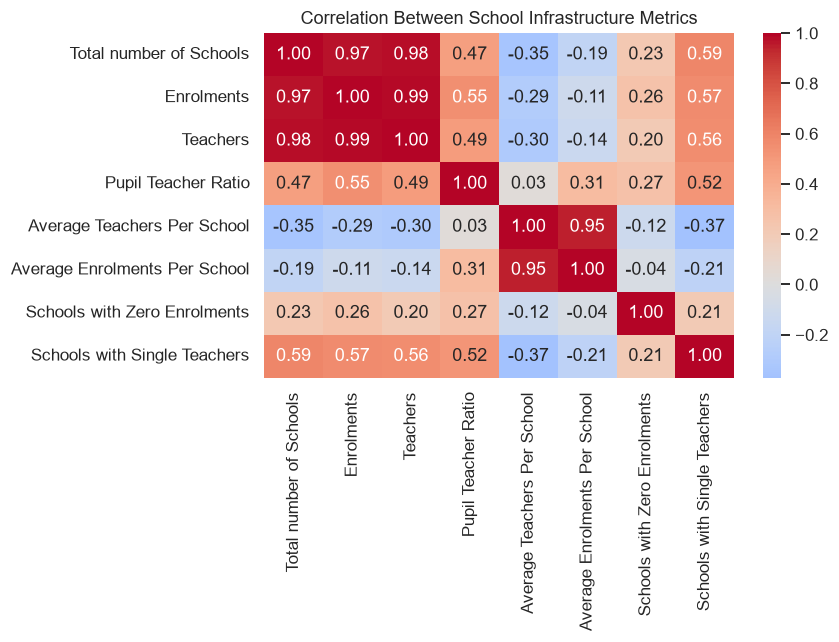

In [22]:
################################### How Do Infrastructure Metrics Correlate?#########################################
num_cols = ["Total number of Schools", "Enrolments", "Teachers", "Pupil Teacher Ratio",
            "Average Teachers Per School", "Average Enrolments Per School",
            "Schools with Zero Enrolments", "Schools with Single Teachers"]
plt.figure(figsize=(8, 6))
sns.heatmap(infra_states[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between School Infrastructure Metrics")
plt.tight_layout()
plt.show()